### Import Required Libraries 


In [19]:
#Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### Load Dataset

In [20]:
df = pd.read_csv("bank-marketing.csv")
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


### Data Visualization 

In [24]:
df.shape


(45211, 17)

In [25]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')

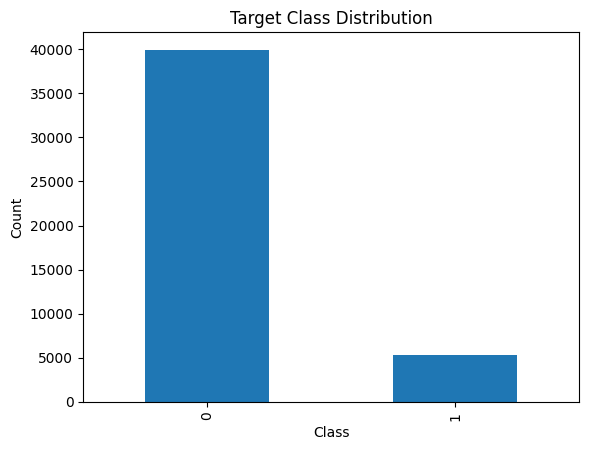

In [26]:
df['Class'].value_counts().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Data Preprocessing 

In [ ]:

df['Class'] = df['Class'].replace({1: 0, 2: 1})
print("Unique values in Class:", df['Class'].unique())

In [21]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


Unique values in Class: [0 1]


In [22]:
#split features and target 
X = df.drop('Class', axis=1)
y = df['Class']


### Split Feature and Target


### Split Dataset intro Train and Test 

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Initialized Random Forest 

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42) 
rf.fit(X_train, y_train) #train each tree
y_pred = rf.predict(X_test) #aggregate predictions 


### Model Evalution 

In [10]:
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Random Forest Accuracy: 0.9016919163994249

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.64      0.42      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



### ROC Curve 

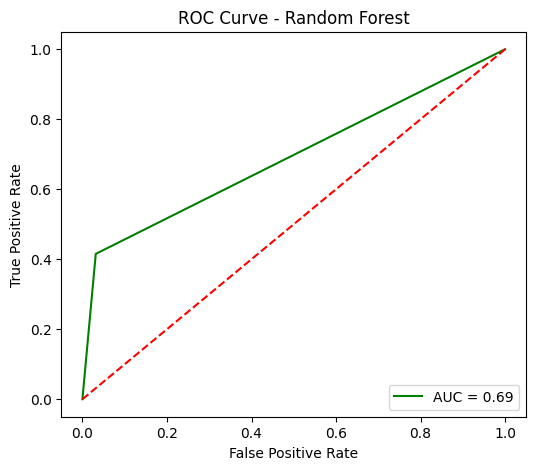

In [11]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # Random guess line
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()